In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
       print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nfl-big-data-bowl-2026-prediction/test_input.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/test.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/nfl_inference_server.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/nfl_gateway.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/__init__.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/templates.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/base_gateway.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/relay.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/kaggle_evaluation.proto
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/__init__.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/generated/kaggle_evaluati

In [2]:
# Helping functions
# Expand each row into multiple rows (one per frame)

def create_prediction_grid(summary):
    expanded = (
        summary
        .loc[summary.index.repeat(summary['num_frames_output'])]
        .assign(frame=lambda df: df.groupby(df.index).cumcount() + 1)
    )
    
    # Create the ID column
    expanded['id'] = (
        expanded['game_id'].astype(str) + '_' +
        expanded['play_id'].astype(str) + '_' +
        expanded['nfl_id'].astype(str) + '_' +
        expanded['frame'].astype(str)
    )
    
    # Add placeholder x,y columns
    expanded['x'] = 0
    expanded['y'] = 0
    
    # Select final columns and reset index
    submission = expanded[['id', 'x', 'y']].reset_index(drop=True)  
    return submission

Some rules
- Need to code that attackers always go left to right
- 

# The input data contains tracking data before the pass is thrown

- game_id: Game identifier, unique (numeric)
- play_id: Play identifier, not unique across games (numeric)
- player_to_predict: whether or not the x/y prediction for this player will be scored (bool)
- nfl_id: Player identification number, unique across players (numeric)
- frame_id: Frame identifier for each play/type, starting at 1 for each game_id/play_id/file type (input or output) (numeric)
play_direction: Direction that the offense is moving (left or right)
absolute_yardline_number: Distance from end zone for possession team (numeric)
player_name: player name (text)
player_height: player height (ft-in)
player_weight: player weight (lbs)
player_birth_date: birth date (yyyy-mm-dd)
player_position: the player's position (the specific role on the field that they typically play)
player_side: team player is on (Offense or Defense)
player_role: role player has on play (Defensive Coverage, Targeted Receiver, Passer or Other Route Runner)
x: Player position along the long axis of the field, generally within 0 - 120 yards. (numeric)
y: Player position along the short axis of the field, generally within 0 - 53.3 yards. (numeric)
s: Speed in yards/second (numeric)
a: Acceleration in yards/second^2 (numeric)
o: orientation of player (deg)
dir: angle of player motion (deg)
num_frames_output: Number of frames to predict in output data for the given game_id/play_id/nfl_id. (numeric)
ball_land_x: Ball landing position position along the long axis of the field, generally within 0 - 120 yards. (numeric)
ball_land_y: Ball landing position along the short axis of the field, generally within 0 - 53.3 yards. (numeric)
output_2023_w[01-18].csv
The output data contains tracking data after the pass is thrown.

game_id: Game identifier, unique (numeric)
play_id: Play identifier, not unique across games (numeric)
nfl_id: Player identification number, unique across players. (numeric)
frame_id: Frame identifier for each play/type, starting at 1 for each game_id/play_id/ file type (input or output). The maximum value for a given game_id, play_id and nfl_id will be the same as the num_frames_output value from the corresponding input file. (numeric)
x: Player position along the long axis of the field, generally within 0-120 yards. (TARGET TO PREDICT)
y: Player position along the short axis of the field, generally within 0 - 53.3 yards. (TARGET TO PREDICT)

In [3]:
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#       df = pd.read_csv(os.path.join(dirname, filename))
#        print(os.path.join(dirname, filename))


input_df = pd.read_csv("/kaggle/input/nfl-big-data-bowl-2026-prediction/train/input_2023_w08.csv")
output_df =  pd.read_csv("/kaggle/input/nfl-big-data-bowl-2026-prediction/train/output_2023_w08.csv")


In [4]:
input_df.head(100)

game = input_df[input_df['game_id'] == 	2023102600]
play = game[game['play_id'] == 109]
play = play[play['player_to_predict']== True]
play

player = play[play['player_role'] == 'Targeted Receiver']



out_game = output_df[output_df['game_id'] == 	2023102600]
out_play = out_game[out_game['play_id'] == 109]
out_play

#play['player_role'].unique()
#play['player_name'].unique()

,game_id,play_id,nfl_id,frame_id,x,y
0,2023102600,109,54650,1,70.87,35.44
1,2023102600,109,54650,2,70.45,35.58
2,2023102600,109,54650,3,70.05,35.74
3,2023102600,109,54650,4,69.66,35.92
4,2023102600,109,54650,5,69.28,36.11
5,2023102600,109,54650,6,68.94,36.26
6,2023102600,109,54650,7,68.62,36.36
7,2023102600,109,54650,8,68.31,36.44
8,2023102600,109,54650,9,68.03,36.47
9,2023102600,109,54650,10,67.76,36.48


In [5]:
output_df.head()

,game_id,play_id,nfl_id,frame_id,x,y
0,2023102600,109,54650,1,70.87,35.44
1,2023102600,109,54650,2,70.45,35.58
2,2023102600,109,54650,3,70.05,35.74
3,2023102600,109,54650,4,69.66,35.92
4,2023102600,109,54650,5,69.28,36.11


### Okay lets make a base prediction

### EDA

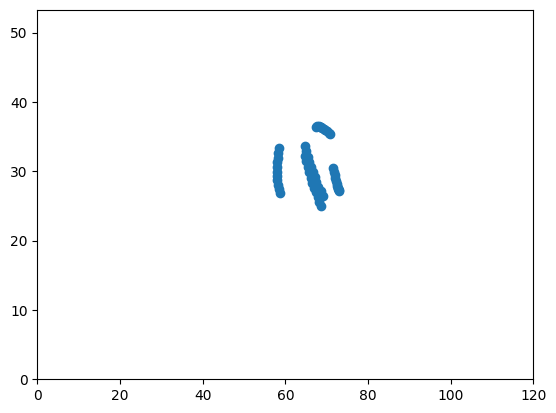

/tmp/ipykernel_13/2562419189.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap(cmap_name, n)


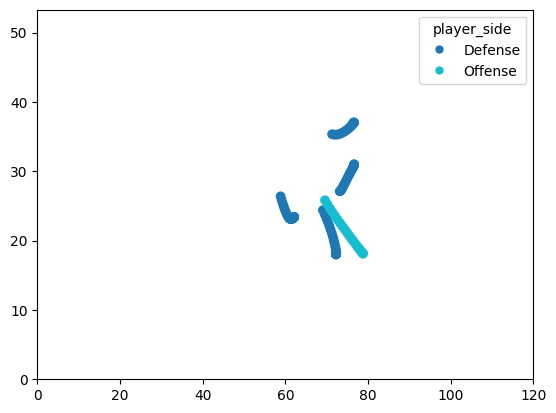

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D

def pitch_plot(x, y, color=None, cmap_name='tab10', title=None):
    # Ensure Series (keeps indexes for alignment)
    x = pd.Series(x)
    y = pd.Series(y)

    fig, ax = plt.subplots()

    if color is None:
        # No color argument: just plot points
        ax.scatter(x, y)
    else:
        # Align color to x/y rows by index (prevents length mismatches)
        c = pd.Series(color).reindex(x.index)

        if len(c) != len(x):
            raise ValueError(f"'color' length {len(c)} does not match x/y length {len(x)} after alignment.")

        # If color is non-numeric (categorical), map to codes + legend
        if not pd.api.types.is_numeric_dtype(c):
            cats = pd.Categorical(c)
            codes = cats.codes  # -1 for NaN; map those to a default color
            n = max(len(cats.categories), 1)
            cmap = get_cmap(cmap_name, n)
            # Replace -1 (NaN) with a distinct index at the end, if any NaNs exist
            if (codes == -1).any():
                codes = pd.Series(codes)
                codes[codes == -1] = n - 1
            ax.scatter(x, y, c=codes, cmap=cmap)

            # Legend (skip NaN label)
            handles = [
                Line2D([], [], marker='o', linestyle='', label=str(cat),
                       markerfacecolor=cmap(i), markeredgecolor='none')
                for i, cat in enumerate(cats.categories)
                if str(cat) != 'nan'
            ]
            if handles:
                ax.legend(handles=handles, title=getattr(c, 'name', 'Category'), loc='best')
        else:
            # Numeric color values → use default normalization/colorbar
            sc = ax.scatter(x, y, c=c)
            plt.colorbar(sc, ax=ax)

    ax.set(xlim=(0, 120), ylim=(0, 53.3))
    if title:
        ax.set_title(title)
    plt.show()


# 1) No color argument
pitch_plot(out_play['x'], out_play['y'])

# 2) Same-df categorical colors
pitch_plot(play['x'], play['y'], play['player_side'])

In [7]:
#out_play['part'] = 'output'
#play['part'] = 'input'

summary = play[['game_id', 'play_id', 'nfl_id', 'num_frames_output']].drop_duplicates()
prediction = create_prediction_grid(summary)

def test_format(test: pd.DataFrame) -> pd.DataFrame:
    """
    Given columns ['game_id', 'play_id', 'nfl_id', 'frame_id', 'x', 'y'],
    create an 'id' column formatted as 'gameid_playid_nflid_frameid'
    and return only ['id', 'x', 'y'].
    """
    test = test.copy()
    
    # Create id string
    test['id'] = (
        test['game_id'].astype(str) + '_' +
        test['play_id'].astype(str) + '_' +
        test['nfl_id'].astype(str) + '_' +
        test['frame_id'].astype(str)
    )

    # Keep only required columns
    test = test[['id', 'x', 'y']]
    return test



def get_rmse(prediction, actual):
    """
    Compute RMSE between two DataFrames with columns ['id', 'x', 'y'].
    Matches rows by 'id' and compares corresponding x, y values.
    """
    # Merge on 'id' to align predictions and actuals
    merged = pd.merge(prediction, actual, on='id', suffixes=('_pred', '_actual'))
    
    # Compute squared error for both x and y
    mse = np.mean(
        (merged['x_pred'] - merged['x_actual'])**2 + 
        (merged['y_pred'] - merged['y_actual'])**2
    )
    
    # Root Mean Squared Error
    rmse = np.sqrt(mse)
    return rmse
#test_format(out_play)
val = test_format(out_play)
val['x'] = 60
val['y'] = 26
#val.head()
get_rmse(prediction,val)

65.39113089708727

In [8]:
#pd.read_csv('/kaggle/input/nfl-big-data-bowl-2026-prediction/sample_submission.csv')

In [9]:
#pd.read_csv('/kaggle/input/nfl-big-data-bowl-2026-prediction/sample_submission.csv')

In [10]:
pd.read_csv('/kaggle/input/nfl-big-data-bowl-2026-prediction/test.csv')

,id,game_id,play_id,nfl_id,frame_id
0,12350,2024120805,74,54586,1
1,12351,2024120805,74,54586,2
2,12352,2024120805,74,54586,3
3,12353,2024120805,74,54586,4
4,12354,2024120805,74,54586,5
...,...,...,...,...,...
5832,157629,2025010515,3902,55112,26
5833,157630,2025010515,3902,55112,27
5834,157631,2025010515,3902,55112,28
5835,157632,2025010515,3902,55112,29


Final Submission

In [11]:
# Helping functions
# Expand each row into multiple rows (one per frame)

def create_prediction_grid(summary):
    expanded = (
        summary
        .loc[summary.index.repeat(summary['num_frames_output'])]
        .assign(frame=lambda df: df.groupby(df.index).cumcount() + 1)
    )
    
    # Create the ID column
    expanded['id'] = (
        expanded['game_id'].astype(str) + '_' +
        expanded['play_id'].astype(str) + '_' +
        expanded['nfl_id'].astype(str) + '_' +
        expanded['frame'].astype(str)
    )
    
    # Add placeholder x,y columns
    expanded['x'] = 0
    expanded['y'] = 0
    
    # Select final columns and reset index
    submission = expanded[['id', 'x', 'y']].reset_index(drop=True)  
    return submission
test_input = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2026-prediction/test_input.csv')
test_input = test_input[test_input['player_to_predict']== True]
summary = test_input[['game_id', 'play_id', 'nfl_id', 'num_frames_output']].drop_duplicates()




submission = create_prediction_grid(summary)
submission.to_parquet('submission.parquet')


In [12]:
import polars as pl

import kaggle_evaluation.nfl_inference_server


def predict(test: pl.DataFrame, test_input: pl.DataFrame) -> pl.DataFrame | pd.DataFrame:
    """Replace this function with your inference code.
    You can return either a Pandas or Polars dataframe, though Polars is recommended for performance.
    Each batch of predictions (except the very first) must be returned within 5 minutes of the batch features being provided.
    """
    predictions = pl.DataFrame({'x': [0.0] * len(test), 'y': [0.0] * len(test)})

    assert isinstance(predictions, (pd.DataFrame, pl.DataFrame))
    assert len(predictions) == len(test)
    return predictions



# When your notebook is run on the hidden test set, inference_server.serve must be called within 10 minutes of the notebook starting
# or the gateway will throw an error. If you need more than 15 minutes to load your model you can do so during the very
# first `predict` call, which does not have the usual 5 minute response deadline.
inference_server = kaggle_evaluation.nfl_inference_server.NFLInferenceServer(predict)


if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    inference_server.serve()
else:
    inference_server.run_local_gateway(('/kaggle/input/nfl-big-data-bowl-2026-prediction/',))